## Building QnA System with RAG

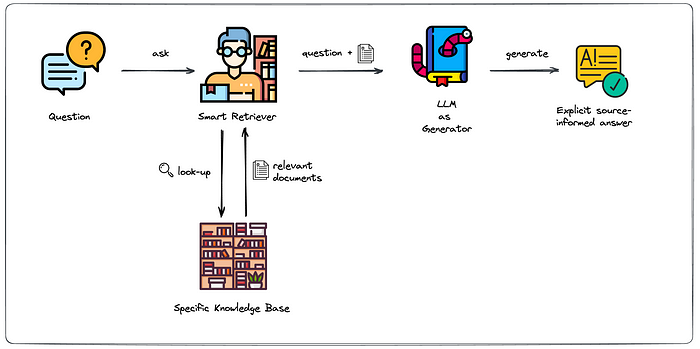

We will have two parts:

- Part 1. Tuning the Embedding Model (which gives most relevant docs given the query)
- Part 2. Tuning the Generator Model (which gives the most accurate answer given (question, relevant docs)

### Evaluation Metric

Evalution on Third Kaggle Competition consists of 3 steps:
- Step 1. Precision of Retriever - how many false positives Retriever found. Precision measures how many of retrieved documents were actually relevant. Higher the precision - lower the amount of false positives. Precision = TP / (TP + FP)
- Step 2. Recall of Retriever - how many false negatives Retriever has. Recall measures how many of relevant documents were actually retrieved. Higher the recall - lower the amount of false negatives. Recall = TP / (TP + FN)
- Step 3. BLEU score of Generator - how similar is your answer to the ground truth answer. Higher the BLEU - the better your answer is.

Final Metric is the linear combination of (Precision + Recall + BLEU) / 3

### Dataset Downloading

In [1]:
!pip install wldhx.yadisk-direct datasets evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 18.7 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.

In [2]:
!curl -L $(yadisk-direct https://disk.yandex.ru/d/HpBl9kxYSaVSqw) -o data.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:--  0:00:01 --:--:--     0
100 15.2M  100 15.2M    0     0  2469k      0  0:00:06  0:00:06 --:--:-- 3797k


In [3]:
!unzip data.zip >> /dev/null

### Dataset Preparation

In [4]:
import numpy as np
import pandas as pd

documents_df = pd.read_csv('kaggle_3_documents.csv')

In [5]:
documents_df

,id,passage
0,9797,New data on viruses isolated from patients wit...
1,11906,We describe an improved method for detecting d...
2,16083,We have studied the effects of curare on respo...
3,23188,Kinetic and electrophoretic properties of 230-...
4,23469,Male Wistar specific-pathogen-free rats aged 2...
...,...,...
40216,34885209,LncRNAs are involved in the occurrence and pro...
40217,34886835,BACKGROUND: COVID-19 patients with long incuba...
40218,34888619,Spinal muscular atrophy (SMA) is an autosomal ...
40219,34893673,Amphiregulin (AREG) is an epidermal growth fac...


In [6]:
train_df = pd.read_csv('kaggle_3_train.csv')

In [7]:
train_df

,id,question,answer,relevant_passage_ids
0,164,What is the enzymatic activity of the breast c...,E3-ubiquitin ligase activity is the only known...,"[20681793, 22034435, 19088202, 16479151, 24278..."
1,1816,What is the effect of CPEB3 binding to the CPE...,The cytoplasmic polyadenylation element (CPE) ...,"[17923234, 17481902, 25066254, 23776146, 26398..."
2,4363,Which disease do pathogenic NR2F1 variants cause?,Bosch-Boonstra-Schaaf optic atrophy syndrome (...,[26986877]
3,753,Which enzyme is deficient in Gaucher's disease?,Gaucher's disease is caused by deficient lysos...,"[20946052, 18627336, 16781064, 22843412, 24485..."
4,2314,What does davunetide do to microtubules?,Davunetide or NAP is a microtubule-stabilizer.,[24210139]
...,...,...,...,...
3770,4223,Has the companion diagnostic HercepTest receiv...,"Yes, the HercepTest has received FDA approval.",[30668632]
3771,1943,What does the human ABCC gene product do?,The important drug resistance-conferring membe...,"[11483364, 16815813, 19118502, 20712617, 21740..."
3772,1049,Approximately how many recombination hotspots ...,In the fission yeast genome DSBs are located w...,"[19557188, 16640774, 18682829, 8290959, 174785..."
3773,3957,Which diseases are associated with the Yaa gene?,The Y-linked autoimmune accelerating gene muta...,"[8181531, 16777955, 9743333, 2599002, 18521959..."


In [8]:
train_df[train_df['id']==164]

,id,question,answer,relevant_passage_ids
0,164,What is the enzymatic activity of the breast c...,E3-ubiquitin ligase activity is the only known...,"[20681793, 22034435, 19088202, 16479151, 24278..."


In [9]:
test_df = pd.read_csv('kaggle_3_test.csv')
test_df

,id,question
0,1840,What is the function of Oseltamivir when admin...
1,1300,What is known about diseases associated with m...
2,2103,What is the applicability of the No Promoter L...
3,3122,What is patisiran?
4,2813,What is vcfanno?
...,...,...
939,3001,What is CardioClassifier?
940,882,Is nivolumab used for treatment of Non–Small-C...
941,3259,List the cancers that are associated with SBLA...
942,446,Which disease can be treated with Delamanid?


## Introduction to the Question-Answering Task

#### Modern QA systems often consist of two primary parts:

- Retriever: Finds the most relevant documents or passages that might contain the answer to a question.
- Generator: Uses the retrieved information to craft a final answer in natural language.

By splitting a QA system into a retriever and a generator, we can handle large-scale data more efficiently and ensure the final answers are accurate and coherent.

### The Retriever: Finding the Right Information

Imagine you have a huge library of books. A friend asks you a question, and you need to find which book (and which page) has the information needed to answer them. That’s essentially what the retriever does:

- Search: The retriever searches through a large pool of documents (e.g., web articles, Wikipedia pages, or scientific papers) to find the most relevant text snippets.
- Filtering: It filters out irrelevant information so that only useful, on-topic passages remain.
- Efficiency: A well-designed retriever cuts down the total amount of text passed to the generator, which speeds up the system and boosts accuracy.


#### Why Retrieval Is Crucial
- Scalability: You can maintain huge collections of documents without overloading your system at generation time.
- Accuracy: Generators work best when they have focused, high-quality source text to draw from.


### The Generator: Crafting the Answer

Once the retriever has identified the relevant passages, the generator takes over to create a concise, human-like answer. Here’s how:

- Reading: The generator reads the retrieved text carefully.
- Reasoning: It pieces together the key facts and context to address the user’s question directly.
- Writing: Finally, it produces a clear, coherent response in natural language—like a teacher explaining the answer to a student.

#### Why Generation Matters
- Clarity: Instead of just copying text, a generator can interpret and summarize information, making the answer more understandable.
- Flexibility: Generators can answer various types of questions (factual, explanatory, etc.) and adapt their style (short answer, longer explanation, etc.).

                          ┌────────────────────┐
                          │    User Query      │
                          └────────┬───────────┘
                                   │
                              (1) The user
                                   │
                                   v
                      ┌─────────────────────────┐
                      │   Embedding Model       │
                      │ (creates query vectors) │
                      └────────┬────────────────┘
                                   │
                          (2) Query Embedding
                                   │
                                   v
                      ┌─────────────────────────┐
                      │        Retriever        │
                      │ (searches document DB)  │
                      └────────┬────────────────┘
                                   │
                    (3) Relevant Documents/Passages
                                   │
                                   v
                      ┌─────────────────────────┐
                      │    Generator Model      │
                      │ (produces final answer) │
                      └────────┬────────────────┘
                                   │
                         (4) Final Answer Text
                                   │
                                   v
                          ┌────────────────────┐
                          │    User Output     │
                          └────────────────────┘


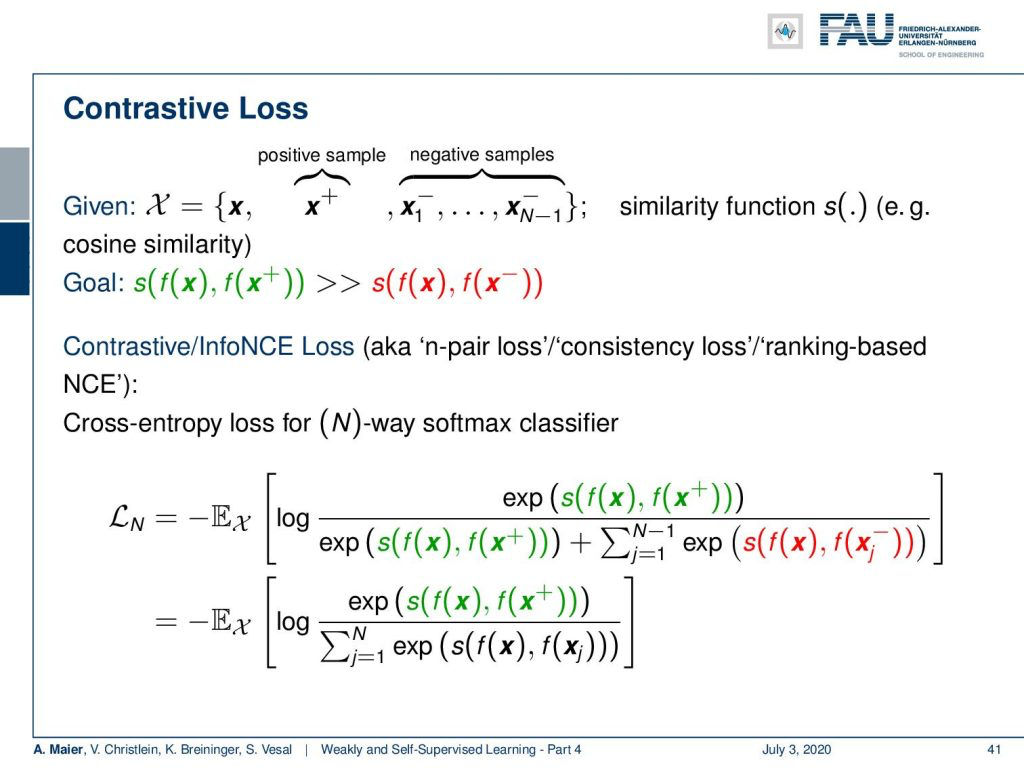

## Part 1. Creating the Retriever dataset and Retriever model

In [7]:
documents_df

,id,passage
0,9797,New data on viruses isolated from patients wit...
1,11906,We describe an improved method for detecting d...
2,16083,We have studied the effects of curare on respo...
3,23188,Kinetic and electrophoretic properties of 230-...
4,23469,Male Wistar specific-pathogen-free rats aged 2...
...,...,...
40216,34885209,LncRNAs are involved in the occurrence and pro...
40217,34886835,BACKGROUND: COVID-19 patients with long incuba...
40218,34888619,Spinal muscular atrophy (SMA) is an autosomal ...
40219,34893673,Amphiregulin (AREG) is an epidermal growth fac...


In [8]:
train_df

,id,question,answer,relevant_passage_ids
0,164,What is the enzymatic activity of the breast c...,E3-ubiquitin ligase activity is the only known...,"[20681793, 22034435, 19088202, 16479151, 24278..."
1,1816,What is the effect of CPEB3 binding to the CPE...,The cytoplasmic polyadenylation element (CPE) ...,"[17923234, 17481902, 25066254, 23776146, 26398..."
2,4363,Which disease do pathogenic NR2F1 variants cause?,Bosch-Boonstra-Schaaf optic atrophy syndrome (...,[26986877]
3,753,Which enzyme is deficient in Gaucher's disease?,Gaucher's disease is caused by deficient lysos...,"[20946052, 18627336, 16781064, 22843412, 24485..."
4,2314,What does davunetide do to microtubules?,Davunetide or NAP is a microtubule-stabilizer.,[24210139]
...,...,...,...,...
3770,4223,Has the companion diagnostic HercepTest receiv...,"Yes, the HercepTest has received FDA approval.",[30668632]
3771,1943,What does the human ABCC gene product do?,The important drug resistance-conferring membe...,"[11483364, 16815813, 19118502, 20712617, 21740..."
3772,1049,Approximately how many recombination hotspots ...,In the fission yeast genome DSBs are located w...,"[19557188, 16640774, 18682829, 8290959, 174785..."
3773,3957,Which diseases are associated with the Yaa gene?,The Y-linked autoimmune accelerating gene muta...,"[8181531, 16777955, 9743333, 2599002, 18521959..."


In [9]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader
from datasets import Dataset
from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer, losses, models, util, InputExample
from sentence_transformers.evaluation import InformationRetrievalEvaluator
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import logging
import os
from tqdm.auto import tqdm
import sys

# Set up logging for convenience
root = logging.getLogger()
root.setLevel(logging.DEBUG)

handler = logging.StreamHandler(sys.stdout)
handler.setLevel(logging.DEBUG)
formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
handler.setFormatter(formatter)
root.addHandler(handler)


class Retriever:
    """
    A simple unified retriever that:
      1. Loads a corpus of documents (id -> text).
      2. Prepares train data (with negative sampling).
      3. Splits some data for evaluation.
      4. Trains a SentenceTransformer model for information retrieval.
      5. Evaluates using IR metrics on the held-out set.
      6. Retrieves top-k passages for queries (including test data).
    """

    def __init__(self, model_name="distilbert-base-uncased"):
        """
        Initialize a SentenceTransformer model.

        Args:
            model_name (str): Name of the transformer model to load.
        """
        logging.info(f"Initializing model: {model_name}")
        self.model = SentenceTransformer(model_name)

        # Internal caches and placeholders
        self.corpus = {}           # dict of {doc_id -> passage}
        self.corpus_ids = []       # list of doc_ids
        self.corpus_texts = []     # list of passages
        self.corpus_embeddings = None

        # For training/evaluation
        self.train_examples = []
        self.queries = {}          # {query_id: query_text} used for IR evaluation
        self.relevant_docs = {}    # {query_id: {doc_id: 1}}

    ###########################################################################
    #                  1. LOADING THE CORPUS DOCUMENTS                        #
    ###########################################################################

    def load_corpus(self, documents_df):
        """
        Load the corpus documents into memory.

        Args:
            documents_df (pd.DataFrame): Must have columns ['id', 'passage']
        """
        logging.info("Loading corpus documents...")
        # Convert passages to string, fill NAs if necessary
        documents_df['passage'] = documents_df['passage'].fillna("").astype(str)

        self.corpus = dict(zip(documents_df['id'].astype(str), documents_df['passage']))
        self.corpus_ids = list(self.corpus.keys())
        self.corpus_texts = list(self.corpus.values())

        logging.info(f"Corpus size: {len(self.corpus)} documents.")

    ###########################################################################
    #                  2. PREPARING TRAIN DATA (NEGATIVE SAMPLING)           #
    ###########################################################################

    def prepare_data(self, train_df, negative_samples=3, eval_ratio=0.2):
        """
        Prepares training data (with negative samples) and an evaluation set.

        Args:
            train_df (pd.DataFrame): Must have columns ['id', 'question', 'relevant_passage_ids']
            negative_samples (int): Number of negative samples per query
            eval_ratio (float): Fraction of train_df to hold out for evaluation
        """
        if not self.corpus:
            raise ValueError("No corpus loaded. Call load_corpus(documents_df) first.")

        # Convert questions to string, fill NAs if necessary
        train_df['question'] = train_df['question'].fillna("").astype(str)

        # Determine eval set
        total_len = len(train_df)
        eval_size = int(eval_ratio * total_len)
        eval_indices = set(np.random.choice(range(total_len), size=eval_size, replace=False))

        train_examples = []
        queries = {}
        relevant_docs = {}

        # For each row in train data, build positive/negative examples
        for idx, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Preparing data"):
            qid = str(row['id'])  # query id
            question_text = row['question']

            # Convert "[2, 5]" -> ["2", "5"]
            rel_ids = [
                x.strip() for x in row['relevant_passage_ids'].strip('[]').split(',')
            ]
            rel_ids = [r for r in rel_ids if r]  # filter out empty strings if any

            # Positive examples
            for rid in rel_ids:
                if rid in self.corpus:
                    train_examples.append(InputExample(
                        texts=[question_text, self.corpus[rid]],
                        label=1.0
                    ))

            # Negative examples (random sample passages not in rel_ids)
            all_irrelevant_ids = [pid for pid in self.corpus.keys() if pid not in rel_ids]
            if len(all_irrelevant_ids) > 0 and negative_samples > 0:
                neg_sample = np.random.choice(
                    all_irrelevant_ids,
                    min(negative_samples, len(all_irrelevant_ids)),
                    replace=False
                )
                for nid in neg_sample:
                    train_examples.append(InputExample(
                        texts=[question_text, self.corpus[nid]],
                        label=0.0
                    ))

            # If this index is in eval set, store queries/relevant_docs
            if idx in eval_indices:
                queries[qid] = question_text
                relevant_docs[qid] = {doc_id: 1 for doc_id in rel_ids if doc_id in self.corpus}

        self.train_examples = train_examples
        self.queries = queries
        self.relevant_docs = relevant_docs

        logging.info(f"Total training examples: {len(self.train_examples)}")
        logging.info(f"Eval queries: {len(self.queries)}; corpus size: {len(self.corpus)}")

    ###########################################################################
    #                  3. TRAINING THE MODEL                                  #
    ###########################################################################

    def train(self,
              epochs=1,
              evaluation_steps=250,
              warmup_steps=200,
              output_path="output/biomedical-retrieval-model"):
        """
        Train the SentenceTransformer model on the prepared training examples,
        evaluate on the held-out portion, and save the model.

        Args:
            epochs (int): Number of training epochs
            evaluation_steps (int): Frequency of evaluation steps
            warmup_steps (int): Warmup steps for the scheduler
            output_path (str): Where to save the model
        """
        if not self.train_examples:
            raise ValueError("No training examples found. Run prepare_data(...) first.")

        logging.info(f"Training model on {len(self.train_examples)} examples...")
        train_dataloader = DataLoader(self.train_examples, batch_size=16, shuffle=True)
        train_loss = losses.MultipleNegativesRankingLoss(self.model)

        # Create IR evaluator for the held-out set
        if len(self.queries) > 0:
            ir_evaluator = InformationRetrievalEvaluator(
                queries={qid: str(q) for qid, q in self.queries.items()},
                corpus={doc_id: str(doc) for doc_id, doc in self.corpus.items()},
                relevant_docs=self.relevant_docs
            )
        else:
            ir_evaluator = None

        # Fit the model
        logging.info("Starting training...")
        self.model.fit(
            train_objectives=[(train_dataloader, train_loss)],
            evaluator=ir_evaluator,
            epochs=epochs,
            evaluation_steps=evaluation_steps if ir_evaluator else 0,
            warmup_steps=warmup_steps,
            output_path=output_path
        )
        logging.info("Training complete!")
        logging.info("Don’t forget to recompute corpus embeddings if the corpus changed!")

    ###########################################################################
    #                  4. ONE-STOP CONVENIENCE METHOD: FIT                    #
    ###########################################################################

    def fit(self,
            train_df: pd.DataFrame,
            negative_samples=3,
            eval_ratio=0.2,
            epochs=1,
            evaluation_steps=250,
            warmup_steps=200,
            output_path="output/biomedical-retrieval-model"):
        """
        Convenience method to prepare data and then train in one shot.

        Args:
            train_df (pd.DataFrame): Must have columns ['id', 'question', 'relevant_passage_ids']
            negative_samples (int): Number of negative samples per query
            eval_ratio (float): Fraction of train_df to hold out for evaluation
            epochs (int): Number of epochs
            evaluation_steps (int): Evaluate after every X steps
            warmup_steps (int): Warmup steps for scheduler
            output_path (str): Output path for saving the trained model
        """
        # 1. Prepare the data
        self.prepare_data(train_df, negative_samples=negative_samples, eval_ratio=eval_ratio)
        # 2. Train the model
        self.train(epochs=epochs,
                   evaluation_steps=evaluation_steps,
                   warmup_steps=warmup_steps,
                   output_path=output_path)

    ###########################################################################
    #                  5. PRECOMPUTE CORPUS EMBEDDINGS                        #
    ###########################################################################

    def precompute_corpus_embeddings(self, batch_size=1024):
        """
        Compute and cache corpus embeddings for faster retrieval.

        Args:
            batch_size (int): Batch size for encoding
        """
        if not self.corpus_texts:
            raise ValueError("No corpus found. Did you run load_corpus(...) first?")

        logging.info(f"Computing embeddings for {len(self.corpus_texts)} passages...")
        all_embeddings = []

        for start_idx in tqdm(range(0, len(self.corpus_texts), batch_size), desc="Encoding corpus"):
            batch = self.corpus_texts[start_idx:start_idx + batch_size]
            batch_embeddings = self.model.encode(
                batch,
                convert_to_tensor=True,
                show_progress_bar=False
            )

            all_embeddings.append(batch_embeddings)

        self.corpus_embeddings = torch.cat(all_embeddings, dim=0)
        logging.info(f"Corpus embeddings shape: {self.corpus_embeddings.shape}")

    ###########################################################################
    #                  6. RETRIEVAL METHODS (TOP-K)                           #
    ###########################################################################

    def retrieve_top_k(self, query, top_k=5):
        """
        Retrieve top_k passages for a single query string.

        Args:
            query (str): The query text
            top_k (int): Number of top results to return

        Returns:
            List[dict]: [{'corpus_id': id, 'passage': ..., 'score': ...}, ...]
        """
        if self.corpus_embeddings is None:
            self.precompute_corpus_embeddings()

        query_embedding = self.model.encode(str(query), convert_to_tensor=True)
        cos_scores = util.cos_sim(query_embedding, self.corpus_embeddings)[0]

        top_results = torch.topk(cos_scores, k=min(top_k, len(self.corpus_texts)))
        scores = top_results[0]
        indices = top_results[1]

        results = []
        for score, idx in zip(scores, indices):
            cid = self.corpus_ids[idx]
            passage = self.corpus[cid]
            results.append({
                'corpus_id': cid,
                'passage': passage,
                'score': score.item()
            })
        return results

    def retrieve_for_test(self, test_df, top_k=5):
        """
        Takes a DataFrame with columns ['id', 'question'],
        retrieves the top_k passages for each question,
        and returns a new DataFrame with the 'relevant_passage_ids'.

        Args:
            test_df (pd.DataFrame): Must have ['id', 'question']
            top_k (int): Number of top results to retrieve

        Returns:
            pd.DataFrame: Copy of test_df with a new column 'relevant_passage_ids'
        """
        if self.corpus_embeddings is None:
            self.precompute_corpus_embeddings()

        queries = test_df['question'].astype(str).tolist()
        query_embeddings = self.model.encode(queries, convert_to_tensor=True)
        cos_scores = util.cos_sim(query_embeddings, self.corpus_embeddings)

        relevant_passage_ids = []
        for i in range(len(test_df)):
            row_scores = cos_scores[i]
            top_values, top_indices = torch.topk(row_scores, k=min(top_k, len(self.corpus_texts)))
            top_k_ids = [self.corpus_ids[idx] for idx in top_indices]
            relevant_passage_ids.append(top_k_ids)

        result_df = test_df.copy()
        result_df['relevant_passage_ids'] = relevant_passage_ids
        return result_df

    ###########################################################################
    #                  7. EVALUATION / METRIC CALCULATION                     #
    ###########################################################################

    def evaluate(self, test_df, top_k=5, metrics_k=10):
        """
        Convenience method to retrieve top-k docs for the test DataFrame
        (which includes ground-truth doc IDs) and compute IR metrics.

        Args:
            test_df (pd.DataFrame): Must have columns ['id', 'question', 'relevant_passage_ids']
            top_k (int): Number of top retrieved docs
            metrics_k (int): K for computing recall@k, precision@k, etc.

        Returns:
            dict: e.g. {'recall@10': ..., 'precision@10': ..., 'mrr': ...}
        """
        # Retrieve top_k for each query
        retrieved_df = self.retrieve_for_test(test_df, top_k=top_k)

        # Convert retrieval results into a dict for metric calculation
        results_dict = {}       # { query_id: [doc_id1, doc_id2, ...] }
        relevant_dict = {}      # { query_id: {doc_id: 1, ...} }

        for idx, row in retrieved_df.iterrows():
            qid = str(row['id'])
            # row['relevant_passage_ids'] is now a list of top_k predicted IDs
            retrieved_ids = row['relevant_passage_ids']
            results_dict[qid] = retrieved_ids

            # For ground-truth, parse from test_df
            # e.g. "[2, 5]" -> ["2", "5"]
            true_ids = [
                x.strip() for x in str(test_df.loc[idx, 'relevant_passage_ids']).strip('[]').split(',')
            ]
            true_ids = [t for t in true_ids if t]
            relevant_dict[qid] = {doc_id: 1 for doc_id in true_ids if doc_id}

        # Compute IR metrics
        return self.evaluate_ir_metrics(results_dict, relevant_dict, k=metrics_k)

    def evaluate_ir_metrics(self, results, relevant_docs, k=10):
        """
        Compute common IR metrics (Recall@k, Precision@k, MRR) given:
          - results: { query_id: [doc_id1, doc_id2, ...] }
          - relevant_docs: { query_id: { doc_id: 1, doc_id: 1, ...} }

        Args:
            results (dict): Retrieval results mapping from query_id to list of doc_ids
            relevant_docs (dict): Ground-truth relevant docs
            k (int): cutoff for recall@k, precision@k

        Returns:
            dict: {'recall@k': ..., 'precision@k': ..., 'mrr': ...}
        """
        recall = self._calculate_recall_at_k(results, relevant_docs, k)
        precision = self._calculate_precision_at_k(results, relevant_docs, k)
        mrr = self._calculate_mrr(results, relevant_docs)
        return {
            f"recall@{k}": recall,
            f"precision@{k}": precision,
            "mrr": mrr
        }

    def _calculate_recall_at_k(self, results, relevant_docs, k=10):
        """Calculate Recall@K across all queries."""
        recalls = []
        for query_id, retrieved_docs in results.items():
            if query_id in relevant_docs:
                relevant = set(relevant_docs[query_id].keys())
                retrieved = set(retrieved_docs[:k])
                if len(relevant) > 0:
                    recall = len(relevant.intersection(retrieved)) / len(relevant)
                    recalls.append(recall)
        return sum(recalls) / len(recalls) if recalls else 0.0

    def _calculate_precision_at_k(self, results, relevant_docs, k=10):
        """Calculate Precision@K across all queries."""
        precisions = []
        for query_id, retrieved_docs in results.items():
            if query_id in relevant_docs:
                relevant = set(relevant_docs[query_id].keys())
                retrieved = set(retrieved_docs[:k])
                if retrieved:
                    precision = len(relevant.intersection(retrieved)) / len(retrieved)
                else:
                    precision = 0.0
                precisions.append(precision)
        return sum(precisions) / len(precisions) if precisions else 0.0

    def _calculate_mrr(self, results, relevant_docs):
        """Calculate Mean Reciprocal Rank."""
        mrr_scores = []
        for query_id, retrieved_docs in results.items():
            if query_id in relevant_docs:
                relevant = set(relevant_docs[query_id].keys())
                for i, doc_id in enumerate(retrieved_docs):
                    if doc_id in relevant:
                        mrr_scores.append(1.0 / (i + 1))
                        break
                else:
                    mrr_scores.append(0.0)
        return sum(mrr_scores) / len(mrr_scores) if mrr_scores else 0.0

In [14]:
!pip install -U bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 132.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 104.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 110.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninsta

In [ ]:
from sentence_transformers import SentenceTransformer
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from transformers import AutoModel, AutoTokenizer, BitsAndBytesConfig
import torch

class LoRASentenceTransformer(SentenceTransformer):
    def __init__(self, model_name_or_path, lora_config=None, **kwargs):
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_use_double_quant=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.bfloat16
        )
        if lora_config is None:
            lora_config = LoraConfig(
                r=8,
                lora_alpha=32,
                target_modules=["query", "key", "value"],
                lora_dropout=0.05,
                bias="none",
                task_type="FEATURE_EXTRACTION"
            )

        super().__init__(model_name_or_path, device="cpu", **kwargs)

        self._first_module().auto_model = self._prepare_lora_model(
            model_name_or_path,
            bnb_config,
            lora_config
        )

        self.to("cuda" if torch.cuda.is_available() else "cpu")

    def _prepare_lora_model(self, model_name, bnb_config, lora_config):
        base_model = AutoModel.from_pretrained(
            model_name,
            quantization_config=bnb_config,
            device_map="auto"
        )

        model = prepare_model_for_kbit_training(base_model)
        lora_model = get_peft_model(model, lora_config)
        lora_model.print_trainable_parameters()

        return lora_model

retriever_model = LoRASentenceTransformer(
    model_name_or_path="BAAI/bge-large-en-v1.5",
    lora_config=LoraConfig(
        r=16,
        lora_alpha=64,
        target_modules = ["query", "key", "value"],
        #target_modules = ["q_proj", "k_proj", "v_proj", "o_proj"],
        lora_dropout=0.1,
        bias="lora_only"
    )
)

retriever = Retriever()
retriever.model = retriever_model

In [ ]:
# retriever = Retriever(model_name="pritamdeka/BioBERT-mnli-snli-scinli-scitail-mednli-stsb")
# retriever = Retriever(model_name="intfloat/e5-large-v2")
# retriever = Retriever(model_name="avsolatorio/GIST-all-MiniLM-L6-v2")
# retriever = Retriever(model_name="intfloat/e5-small")
# retriever = Retriever(model_name="thenlper/gte-base")
# retriever = Retriever(model_name="BAAI/bge-base-en-v1.5")
# retriever = Retriever(model_name="Alibaba-NLP/gte-multilingual-base")

INFO:root:Initializing model: Alibaba-NLP/gte-multilingual-base


2025-04-24 16:31:47,810 - root - INFO - Initializing model: Alibaba-NLP/gte-multilingual-base


INFO:sentence_transformers.SentenceTransformer:Use pytorch device_name: cuda


2025-04-24 16:31:47,838 - sentence_transformers.SentenceTransformer - INFO - Use pytorch device_name: cuda


INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: Alibaba-NLP/gte-multilingual-base


...

2025-04-24 16:31:52,581 - urllib3.connectionpool - DEBUG - https://huggingface.co:443 "HEAD /Alibaba-NLP/gte-multilingual-base/resolve/main/tokenizer_config.json HTTP/1.1" 200 0


DEBUG:urllib3.connectionpool:https://huggingface.co:443 "GET /api/models/Alibaba-NLP/gte-multilingual-base/revision/main HTTP/1.1" 200 227526


2025-04-24 16:31:53,509 - urllib3.connectionpool - DEBUG - https://huggingface.co:443 "GET /api/models/Alibaba-NLP/gte-multilingual-base/revision/main HTTP/1.1" 200 227526


DEBUG:urllib3.connectionpool:https://huggingface.co:443 "GET /api/models/Alibaba-NLP/gte-multilingual-base HTTP/1.1" 200 227526


2025-04-24 16:31:53,769 - urllib3.connectionpool - DEBUG - https://huggingface.co:443 "GET /api/models/Alibaba-NLP/gte-multilingual-base HTTP/1.1" 200 227526


In [11]:
retriever.load_corpus(documents_df)

INFO:root:Loading corpus documents...


2025-04-29 00:35:52,838 - root - INFO - Loading corpus documents...


INFO:root:Corpus size: 40221 documents.


2025-04-29 00:35:52,868 - root - INFO - Corpus size: 40221 documents.


#### Lets test retriever before we trained it

In [ ]:
result_df = retriever.retrieve_for_test(test_df[0:5], top_k=5)
logging.info('First results before training')
result_df

In [ ]:
metrics = retriever.evaluate(train_df, top_k=10, metrics_k=10)
logging.info('Precision and Recall before training')
metrics

In [ ]:
retriever.fit(train_df,
              negative_samples=15,
              eval_ratio=0.2,
              epochs=1,
              evaluation_steps=500,
              warmup_steps=200,
              output_path="output/my-retrieval-model2")

#### Now let's test if we were able to improve Retriever. Precision and Recall should go up

**Important Note**

We must **recompute** corpus embeddings because the Model Weight Matrix has changed after training -> vectors will also change. Do not forget to recompute embeddings after training!

In [ ]:
retriever.precompute_corpus_embeddings()

In [ ]:
metrics = retriever.evaluate(train_df, top_k=10, metrics_k=10)
logging.info('Precision and Recall after training')
metrics

### BIG JUMP ^_^

In [ ]:
result_df = retriever.retrieve_for_test(test_df, top_k=10)

In [18]:
result_df

,id,question,relevant_passage_ids
0,1840,What is the function of Oseltamivir when admin...,"[21677258, 10536125, 16838232, 20635821, 12058..."
1,1300,What is known about diseases associated with m...,"[24934289, 25193783, 22223433, 23533627, 19142..."
2,2103,What is the applicability of the No Promoter L...,"[26530723, 18929641, 26781991, 29687838, 23110..."
3,3122,What is patisiran?,"[28893208, 32311310, 32561705, 34509145, 23613..."
4,2813,What is vcfanno?,"[20089964, 12135664, 15657175, 23146055, 21915..."
...,...,...,...
939,3001,What is CardioClassifier?,"[29369293, 19214293, 30102239, 19007588, 78756..."
940,882,Is nivolumab used for treatment of Non–Small-C...,"[26028407, 29658845, 24685885, 29661758, 27291..."
941,3259,List the cancers that are associated with SBLA...,"[2827818, 8197773, 10640978, 2249207, 27306910..."
942,446,Which disease can be treated with Delamanid?,"[25327169, 26288734, 25431273, 24729727, 27216..."


In [19]:
result_df.to_csv('stage_1_prediction.csv', index=None) # make sure to save the retriever passage ids predictions for test_df
logging.info('We saved the relevant passage ids into the csv file in the case if session crashes')

INFO:root:We saved the relevant passage ids into the csv file in the case if session crashes


2025-04-29 13:05:50,506 - root - INFO - We saved the relevant passage ids into the csv file in the case if session crashes


### Conclusion of Part 1

With just 500 docs and smallest model possible (distilbert), we were able to move precision and recall 10x times higher. Now our retriever will take input query and return much more relevant documents.

Tips on improving the Retriever:
- try to use other family than BERT
- try to use specialized medical embeddings
- visit [MTEB Leaderboard](https://huggingface.co/spaces/mteb/leaderboard) - current State of the Art embedding models and choose any open source embedding
- if you load some Huge embedding model, you might not be able to fully finetune it. Do the Lora/QLora finetuning with HuggingFace. Big Embedding Model + Lora Finetune is a very good choice
- try to change loss to something better
- try to increase negative samples - documents for which the query is **not** relevant

## Part 2. Creating the Generator dataset and Generator model

Generator model accepts as an input question and the context (all relevant documents from Retriever concatenated to big string) and returnss the answer.

If Retriever did a proper job and retrieved factually correct docs, then Generator will very likely generate a good answer. However, there is still value in finetuning Generator.

In [10]:
documents_df.head()

,id,passage
0,9797,New data on viruses isolated from patients wit...
1,11906,We describe an improved method for detecting d...
2,16083,We have studied the effects of curare on respo...
3,23188,Kinetic and electrophoretic properties of 230-...
4,23469,Male Wistar specific-pathogen-free rats aged 2...


In [11]:
train_df.head()

,id,question,answer,relevant_passage_ids
0,164,What is the enzymatic activity of the breast c...,E3-ubiquitin ligase activity is the only known...,"[20681793, 22034435, 19088202, 16479151, 24278..."
1,1816,What is the effect of CPEB3 binding to the CPE...,The cytoplasmic polyadenylation element (CPE) ...,"[17923234, 17481902, 25066254, 23776146, 26398..."
2,4363,Which disease do pathogenic NR2F1 variants cause?,Bosch-Boonstra-Schaaf optic atrophy syndrome (...,[26986877]
3,753,Which enzyme is deficient in Gaucher's disease?,Gaucher's disease is caused by deficient lysos...,"[20946052, 18627336, 16781064, 22843412, 24485..."
4,2314,What does davunetide do to microtubules?,Davunetide or NAP is a microtubule-stabilizer.,[24210139]


In [12]:
import re
import logging
import sys
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import torch

# Hugging Face and evaluation libraries
from transformers import (
    GPT2LMHeadModel,
    GPT2Tokenizer,
    pipeline,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)
from datasets import Dataset
import evaluate
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu

# Set up logging
logger = logging.getLogger(__name__)
logger.setLevel(logging.DEBUG)
handler = logging.StreamHandler(sys.stdout)
handler.setFormatter(logging.Formatter('%(asctime)s - %(levelname)s - %(message)s'))
logger.addHandler(handler)


class Generator:
    """
    A class for training, evaluating, and predicting with a text generation (causal LM) model.

    The class includes methods to:
      1. Build a document dictionary from a DataFrame.
      2. Prepare training data by combining questions, contexts (from relevant passages),
         and answers into prompts.
      3. Tokenize the prompts for training.
      4. Fine-tune the generator using Hugging Face's Trainer.
      5. Evaluate the generator on a sample evaluation set.
      6. Predict answers for a test DataFrame that includes predicted relevant passage IDs.
         In both evaluation and prediction, the prompt is truncated if necessary so that its
         token count plus requested new tokens do not exceed the model’s maximum allowed tokens.
    """

    def __init__(self, model_name="gpt2-medium"):
        logger.info(f"Loading model and tokenizer for {model_name}")
        self.tokenizer = GPT2Tokenizer.from_pretrained(model_name)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token
        self.model = GPT2LMHeadModel.from_pretrained(model_name)
        self.model.config.pad_token_id = self.tokenizer.eos_token_id

        # Placeholders for training data and document dictionary.
        self.doc_dict = {}
        self.qa_df = None
        self.tokenized_dataset = None

    def build_doc_dict(self, documents_df):
        logger.info("Building document dictionary from DataFrame...")
        documents_df["passage"] = documents_df["passage"].fillna("").astype(str)
        self.doc_dict = dict(zip(documents_df["id"].astype(str), documents_df["passage"]))
        logger.info(f"Built doc_dict with {len(self.doc_dict)} documents.")


    def create_prompt(self, question, context, answer=None):
        """
        Build a prompt string with role instruction and concise answer guidance.
        """
        instruction = (
            "You are a biomedical expert. Answer the following question accurately based on the given context. "
            "Only provide the exact answer without any extra explanation."
        )
        if answer:
            prompt = f"{instruction}\n\nQuestion: {question}\nContext: {context}\nAnswer: {answer}"
        else:
            prompt = f"{instruction}\n\nQuestion: {question}\nContext: {context}\nAnswer:"
        return prompt


    def build_truncated_prompt(self, question, context, max_new_tokens):
        """
        Build a prompt while ensuring that its tokenized version does not exceed
        (model's maximum positions - max_new_tokens) tokens. If it does, truncate the context.
        """
        max_positions = self.model.config.n_positions
        # The allowed prompt length is the total positions minus the room we want for new tokens.
        allowed_prompt_length = max_positions - max_new_tokens

        # Build full prompt.
        full_prompt = self.create_prompt(question, context)
        # Tokenize the full prompt.
        inputs = self.tokenizer(full_prompt, return_tensors="pt")
        prompt_length = inputs.input_ids.shape[1]
        if prompt_length <= allowed_prompt_length:
            return full_prompt
        else:
            # Preserve question and "Answer:" markers.
            instruction = (
                "You are a biomedical expert. Answer the following question accurately based on the given context. "
                "Only provide the exact answer without any extra explanation."
            )
            q_part = f"{instruction}\n\nQuestion: {question}\nContext: "
            a_part = "\nAnswer:"


            q_tokens = self.tokenizer(q_part, add_special_tokens=False).input_ids
            a_tokens = self.tokenizer(a_part, add_special_tokens=False).input_ids
            fixed_length = len(q_tokens) + len(a_tokens)
            allowed_for_context = allowed_prompt_length - fixed_length
            # Tokenize the full context.
            context_tokens = self.tokenizer(context, add_special_tokens=False).input_ids
            truncated_context_tokens = context_tokens[:max(allowed_for_context, 0)]
            truncated_context = self.tokenizer.decode(truncated_context_tokens, skip_special_tokens=True)
            truncated_prompt = f"Question: {question}\nContext: {truncated_context}\nAnswer:"
            logger.warning(
                f"Prompt truncated: original length {prompt_length}, "
                f"allowed prompt length {allowed_prompt_length}."
            )
            return truncated_prompt

    def prepare_training_data(self, train_df):
        """
        Prepare training data by combining questions, context from relevant passages, and answers into prompts.

        Expects train_df to have the following columns:
          - 'question'
          - 'answer'
          - 'relevant_passage_ids' : a string representation of a list (e.g., "[2, 5]")

        This method builds an internal DataFrame (self.qa_df) with columns:
          - "question", "relevant_docs" (concatenated passages), "answer", "prompt"

        Args:
            train_df (pd.DataFrame): DataFrame containing training samples.
        """
        if not self.doc_dict:
            raise ValueError("Document dictionary is empty. Call build_doc_dict(documents_df) first.")

        logger.info("Preparing training data from DataFrame...")
        records = []
        for _, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Preparing training data"):
            question = row["question"]
            answer = row["answer"]

            # Clean answer text
            answer = answer.strip()
            prefixes = ["The answer is", "the answer is", "It is", "it is", "This is", "this is"]
            for prefix in prefixes:
                if answer.startswith(prefix):
                    answer = answer[len(prefix):].strip()


            # Parse the relevant_passage_ids string to a list.
            pid_str = str(row["relevant_passage_ids"]).strip("[]")
            doc_ids = [pid.strip() for pid in pid_str.split(",") if pid.strip()]

            # Gather relevant passages based on the doc_dict
            selected_doc_ids = doc_ids[:2]
            relevant_texts = [self.doc_dict[pid] for pid in selected_doc_ids if pid in self.doc_dict]
            combined_passages = " ".join(relevant_texts)



            prompt = self.create_prompt(question, combined_passages, answer)

            records.append({
                "question": question,
                "relevant_docs": combined_passages,
                "answer": answer,
                "prompt": prompt
            })

        self.qa_df = pd.DataFrame(records)
        logger.info(f"Prepared {len(self.qa_df)} training records.")

    def tokenize_training_data(self, max_length=128):
        """
        Convert the prepared training DataFrame into a tokenized Hugging Face Dataset.

        Args:
            max_length (int): Maximum token length for each prompt.
        """
        if self.qa_df is None:
            raise ValueError("Training data not prepared. Call prepare_training_data(train_df) first.")

        logger.info("Converting training data to Dataset and tokenizing...")
        dataset = Dataset.from_pandas(self.qa_df[["prompt"]])

        def tokenize_function(examples):
            return self.tokenizer(
                examples["prompt"],
                padding="max_length",
                truncation=True,
                max_length=max_length
            )

        self.tokenized_dataset = dataset.map(tokenize_function, batched=True)
        logger.info("Tokenization complete.")

    def train_model(self, output_dir="gpt2-medium", num_train_epochs=1, batch_size=4, logging_steps=50):
        """
        Train (fine-tune) the generator model using the tokenized dataset.

        Args:
            output_dir (str): Directory in which to save the fine-tuned model.
            num_train_epochs (int): Number of training epochs.
            batch_size (int): Batch size per device.
            logging_steps (int): Frequency (in steps) at which to log training metrics.
        """
        if self.tokenized_dataset is None:
            raise ValueError("Tokenized training data not found. Run tokenize_training_data(max_length) first.")

        logger.info("Setting up training...")
        data_collator = DataCollatorForLanguageModeling(
            tokenizer=self.tokenizer,
            mlm=False  # GPT-2 uses a causal LM objective, not masked LM
        )


        train_test_split = self.tokenized_dataset.train_test_split(test_size=0.1)
        train_dataset = train_test_split["train"]
        eval_dataset = train_test_split["test"]

        logger.info(f"Split dataset: {len(train_dataset)} training samples, {len(eval_dataset)} evaluation samples")



        training_args = TrainingArguments(
            output_dir=output_dir,
            num_train_epochs=num_train_epochs,
            per_device_train_batch_size=batch_size,
            learning_rate=1e-5,
            gradient_accumulation_steps=4,

            logging_steps=logging_steps,
            eval_strategy="steps",
            eval_steps=50,
            save_strategy="steps",
            save_steps=50,

            save_total_limit=2,  # adjust as needed
            logging_dir=f"{output_dir}/logs",
            fp16=True,  #
            load_best_model_at_end=True,
            metric_for_best_model="loss",
            greater_is_better=False
        )

        trainer = Trainer(
            model=self.model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=eval_dataset,
            # train_dataset=self.tokenized_dataset,
            tokenizer=self.tokenizer,
            data_collator=data_collator,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
        )

        logger.info("Starting training...")
        trainer.train()
        logger.info("Training complete!")

        # Save the model after training
        trainer.save_model(output_dir)
        logger.info(f"Model saved to {output_dir}")

    def evaluate_bert(self, eval_df, max_eval=100, max_new_tokens=32, do_sample=False):
        """
        Evaluate the generator model on a subset of examples using BERTScore.

        This method uses a text generation pipeline with the current model & tokenizer,
        constructs a prompt for each evaluation example, generates an answer,
        and then computes BERTScore F1 between the generated answers and gold answers.

        The eval_df must contain the columns:
        - 'question'
        - 'answer'
        - 'relevant_passage_ids'

        Args:
            eval_df (pd.DataFrame): The evaluation DataFrame.
            max_eval (int): Maximum number of samples to evaluate.
            max_new_tokens (int): Maximum number of new tokens to generate beyond the prompt.
            do_sample (bool): Whether to use sampling during generation.

        Returns:
            tuple: (bert_f1, predictions, references)
                - bert_f1 (float): The average BERTScore F1 score for all evaluation samples.
                - predictions (List[str]): The list of generated answers.
                - references (List[str]): The list of ground-truth answers.
        """
        if not self.doc_dict:
            raise ValueError("Document dictionary is empty. Ensure build_doc_dict(documents_df) has been called.")

        logger.info("Evaluating generator model using BERTScore...")
        gen_pipe = pipeline("text-generation", model=self.model, tokenizer=self.tokenizer)
        # Load the BERTScore metric. (Adjust the language parameter if needed.)

        predictions = []
        references = []
        subset_df = eval_df.sample(n=min(len(eval_df), max_eval), random_state=42)

        for _, row in tqdm(subset_df.iterrows(), total=len(subset_df), desc="Evaluating"):
            question = row["question"]
            gold_answer = row["answer"]

            # Parse relevant passage IDs and combine passages.
            pid_str = str(row["relevant_passage_ids"]).strip("[]")
            doc_ids = [pid.strip() for pid in pid_str.split(",") if pid.strip()]

            # relevant_texts = [self.doc_dict[pid] for pid in doc_ids if pid in self.doc_dict]
            # combined_context = " ".join(relevant_texts)

            # Keep only the top 2 most relevant passages
            selected_doc_ids = doc_ids[:2]
            relevant_texts = [self.doc_dict[pid] for pid in selected_doc_ids if pid in self.doc_dict]
            combined_passages = " ".join(relevant_texts)



            # Build a prompt that is safely truncated.
            # prompt = self.build_truncated_prompt(question, combined_context, max_new_tokens)
            prompt = self.build_truncated_prompt(question, combined_passages, max_new_tokens)

            # Optional: verify prompt length.
            inputs = self.tokenizer(prompt, return_tensors="pt")
            input_length = inputs.input_ids.shape[1]
            if input_length > self.model.config.n_positions - max_new_tokens:
                logger.warning(f"Adjusted prompt length {input_length} exceeds allowed length; further truncation may be needed.")

            gen_output = gen_pipe(
                prompt,
                max_new_tokens=max_new_tokens,
                num_return_sequences=1,
                do_sample=do_sample
            )[0]["generated_text"]

            # Extract the generated answer (everything after "Answer:")
            pred_answer = gen_output.split("Answer:")[-1].strip()
            predictions.append(pred_answer)
            references.append(gold_answer)

        gt = [[x] for x in references]
        pred = predictions
        bleu_score = corpus_bleu(gt, pred)
        logger.info(f"Bleu Score: {bleu_score:.4f}")
        return bleu_score, predictions, references

    def predict(self, test_df, max_new_tokens=32, do_sample=False):
        """
        Generate answers for a test DataFrame containing:
          - 'id', 'question', and 'relevant_passage_ids'
        The generated answers are saved in a new column "answer".
        """
        logger.info("Generating answers for test data...")
        gen_pipe = pipeline("text-generation", model=self.model, tokenizer=self.tokenizer)

        results_df = test_df.copy()
        answers = []

        for _, row in tqdm(results_df.iterrows(), total=len(results_df), desc="Generating answers"):
            question = row["question"]
            pid_str = str(row["relevant_passage_ids"]).strip("[]")
            doc_ids = [pid.strip() for pid in pid_str.split(",") if pid.strip()]
            relevant_texts = [self.doc_dict[pid] for pid in doc_ids if pid in self.doc_dict]
            combined_context = " ".join(relevant_texts)

            # Build a safe prompt via truncation.
            prompt = self.build_truncated_prompt(question, combined_context, max_new_tokens)

            inputs = self.tokenizer(prompt, return_tensors="pt")
            input_length = inputs.input_ids.shape[1]
            if input_length > self.model.config.n_positions - max_new_tokens:
                logger.warning("Prompt length exceeds allowed length after truncation.")

            gen_output = gen_pipe(
                prompt,
                max_new_tokens=max_new_tokens,
                num_return_sequences=1,
                do_sample=do_sample
            )[0]["generated_text"]

            pred_answer = gen_output.split("Answer:")[-1].strip()
            answers.append(pred_answer)

        results_df["answer"] = answers
        logger.info("Answer generation complete.")
        return results_df

In [ ]:
eval_df = train_df.copy()
gen = Generator(model_name="gpt2-medium")

In [ ]:
# Build the document dictionary from documents_df
gen.build_doc_dict(documents_df)

# Prepare and tokenize training data using train_df
gen.prepare_training_data(train_df)
gen.tokenize_training_data(max_length=1024)

In [15]:
# Fine-tune the generator (adjust hyperparameters as needed)
gen.train_model(output_dir="gpt2-medium_2", num_train_epochs=3, batch_size=2, logging_steps=10)

2025-04-29 20:00:29,172 - INFO - Setting up training...


INFO:__main__:Setting up training...


2025-04-29 20:00:29,179 - INFO - Split dataset: 3397 training samples, 378 evaluation samples


INFO:__main__:Split dataset: 3397 training samples, 378 evaluation samples
<ipython-input-12-7f2a6811a4f6>:254: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


2025-04-29 20:00:32,194 - INFO - Starting training...


...

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


2025-04-29 21:13:01,500 - INFO - Training complete!


INFO:__main__:Training complete!


2025-04-29 21:13:06,633 - INFO - Model saved to gpt2-medium_2


INFO:__main__:Model saved to gpt2-medium_2


In [ ]:
# Evaluate the model on the evaluation set
bleu_score, preds, refs = gen.evaluate_bert(eval_df, max_eval=5, max_new_tokens=32, do_sample=False)

print(f"BLEU score: {bleu_score}")
for i in range(len(preds)):
    print(f"\nReference: {refs[i]}\nPrediction: {preds[i]}")


### Big Jump again ^_^

With just 100+ training prompts our BLEU score improved from 0.11 to 0.22. Let's create the Simple Baseline! 💪

### Submission to Kaggle

In [17]:
# retriever_predictions = pd.read_csv('stage_1_prediction.csv') # we load the predictions from Retriever model for 900 test questions

from google.colab import files
import pandas as pd

#uploaded = files.upload()

retriever_predictions = pd.read_csv('/content/stage_1_prediction_6.csv')

retriever_predictions.head()

,id,question,relevant_passage_ids
0,1840,What is the function of Oseltamivir when admin...,"['16838232', '12058885', '21677258', '15750458..."
1,1300,What is known about diseases associated with m...,"['25193783', '24934289', '22033296', '21158681..."
2,2103,What is the applicability of the No Promoter L...,"['26530723', '28191888', '12857799', '32060325..."
3,3122,What is patisiran?,"['28893208', '32311310', '30847674', '28389707..."
4,2813,What is vcfanno?,"['21567923', '20882035', '34670042', '22454754..."


In [18]:
retriever_predictions

,id,question,relevant_passage_ids
0,1840,What is the function of Oseltamivir when admin...,"['16838232', '12058885', '21677258', '15750458..."
1,1300,What is known about diseases associated with m...,"['25193783', '24934289', '22033296', '21158681..."
2,2103,What is the applicability of the No Promoter L...,"['26530723', '28191888', '12857799', '32060325..."
3,3122,What is patisiran?,"['28893208', '32311310', '30847674', '28389707..."
4,2813,What is vcfanno?,"['21567923', '20882035', '34670042', '22454754..."
...,...,...,...
939,3001,What is CardioClassifier?,"['29369293', '30102239', '24402629', '19007588..."
940,882,Is nivolumab used for treatment of Non–Small-C...,"['26028407', '27534574', '26273207', '24402925..."
941,3259,List the cancers that are associated with SBLA...,"['2827818', '2249207', '10640978', '24698998',..."
942,446,Which disease can be treated with Delamanid?,"['25327169', '26288734', '24729727', '25431273..."


In [19]:
def clean_ticks(passage_ids):
    return [str(x).replace('\'','') for x in passage_ids.strip('[]').split(', ')]

In [20]:
retriever_predictions['relevant_passage_ids'] = retriever_predictions['relevant_passage_ids'].apply(clean_ticks)

In [21]:
retriever_predictions

,id,question,relevant_passage_ids
0,1840,What is the function of Oseltamivir when admin...,"[16838232, 12058885, 21677258, 15750458, 20843..."
1,1300,What is known about diseases associated with m...,"[25193783, 24934289, 22033296, 21158681, 17253..."
2,2103,What is the applicability of the No Promoter L...,"[26530723, 28191888, 12857799, 32060325, 23407..."
3,3122,What is patisiran?,"[28893208, 32311310, 30847674, 28389707, 32561..."
4,2813,What is vcfanno?,"[21567923, 20882035, 34670042, 22454754, 14504..."
...,...,...,...
939,3001,What is CardioClassifier?,"[29369293, 30102239, 24402629, 19007588, 21921..."
940,882,Is nivolumab used for treatment of Non–Small-C...,"[26028407, 27534574, 26273207, 24402925, 29658..."
941,3259,List the cancers that are associated with SBLA...,"[2827818, 2249207, 10640978, 24698998, 2930601..."
942,446,Which disease can be treated with Delamanid?,"[25327169, 26288734, 24729727, 25431273, 27216..."


In [ ]:
result_df = gen.predict(retriever_predictions, max_new_tokens=64, do_sample=False)

In [28]:
result_df

,id,question,relevant_passage_ids,answer
0,1840,What is the function of Oseltamivir when admin...,"[16838232, 12058885, 21677258, 15750458, 20843...",Oseltamivir is a non-steroidal anti-inflammato...
1,1300,What is known about diseases associated with m...,"[25193783, 24934289, 22033296, 21158681, 17253...",CHCHD10 is a gene encoding a protein that is i...
2,2103,What is the applicability of the No Promoter L...,"[26530723, 28191888, 12857799, 32060325, 23407...",The No Promoter Left Behind (NLP) method is a ...
3,3122,What is patisiran?,"[28893208, 32311310, 30847674, 28389707, 32561...","Patisiran is a novel, non-invasive, non-invasi..."
4,2813,What is vcfanno?,"[21567923, 20882035, 34670042, 22454754, 14504...",vcfanno is a novel gene-editing tool for the i...
...,...,...,...,...
939,3001,What is CardioClassifier?,"[29369293, 30102239, 24402629, 19007588, 21921...",CardioClassifier is a tool for identifying the...
940,882,Is nivolumab used for treatment of Non–Small-C...,"[26028407, 27534574, 26273207, 24402925, 29658...","Yes, nivolumab is used for treatment of Non–Sm..."
941,3259,List the cancers that are associated with SBLA...,"[2827818, 2249207, 10640978, 24698998, 2930601...",SBLA syndrome is a rare genetic disorder chara...
942,446,Which disease can be treated with Delamanid?,"[25327169, 26288734, 24729727, 25431273, 27216...",Delamanid is a novel drug for the treatment of...


In [29]:
result_df["answer"] = result_df["answer"].fillna("").astype(str)

In [30]:
result_df.loc[result_df['answer']=='','answer'] = 'No answer'

In [31]:
result_df.to_csv('simple_baseline.csv', index=None)

### Conclusion Part 2

With super basic GPT2 model and just a fraction of question/answers pairs we were able to improve the BLEU score.

Your overall Kaggle Metric is (Precision + Recall + BLEU) / 3.

Tips to improve and beat advanced baseline:
- Do **not** use Causal Language Model like GPT, use any Instruction Language Model instead
- Instead of prompt of type 'question:{}, context:{}, answer:{}' switch to the QnA pipeline from huggingface - this will improve BLEU signifficantly. This works very well with the advice about about Instruction LM
- Use Bigger generator models of size at least 7B (GPT 2 that we use has 124 M parameters, it's very tiny, standard GPT 2 with 1.5B params is available in huggingface as `openai-community/gpt2-xl`)
- If you use Bigger Model, you wont be able to finetune all weights. Use LoRA and QLoRA for finetuning. Big Generator Model + LoRA is a good choice
- You will not be able to fit Big Retriever and Big Generator in one Google Colab, so do the work in the teams: 1 person takes the code from part 1 and iterates on Big Retriever, 2-nd person takes the code from part 2 and iterates on Generator.
- P.S. Rewrite the generator/prediction to use GPU batching to increase the speed of predictions significantly. Currently code is doing it sequentially, question by question. This is the task for you to improve your ML Engineering skills :)

Good Luck! 💪